## Similitud - Entidades y condiciones de P2

Se marcan en cada par las condiciones de P2 (montos bajos, salto de tramo, método menos exigente), se encadenan los pares en grupos y se calcula, por entidad, de cada cuántas contrataciones aparece un posible fraccionamiento

### Imports

In [1]:
import os, socket, sys, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, Window, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 200)

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
final_dir = proyecto / "data" / "final"
firmas_dir = proyecto / "02_Similitud" / "temp" / "a_minhash" / "firmas"
pares_dir = proyecto / "02_Similitud" / "temp" / "c_pares" / "pares"
out_dir = proyecto / "02_Similitud" / "temp" / "d_entidades"
out_dir.mkdir(parents=True, exist_ok=True)
entidades_dir = out_dir / "entidades"
pares_p2_dir = out_dir / "pares_p2"

- Funciones

Parámetros y funciones compartidas de `02_Similitud/funciones.ipynb`

In [3]:
ruta_funciones = str(proyecto / "02_Similitud" / "funciones.ipynb")
%run $ruta_funciones

- Figuras y tablas

In [4]:
def mostrar_fig(nombre):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()


def guardar_tabla(df, nombre):
    # parquet para el siguiente notebook + json para la página web
    sdf = spark.createDataFrame(df) if isinstance(df, pd.DataFrame) else df
    sdf.coalesce(1).write.mode("overwrite").parquet(str(tab_dir / nombre))
    sdf.toPandas().to_json(web_dir / f"{nombre}.json", orient="records", force_ascii=False, date_format="iso", indent=1)
    return len(df) if isinstance(df, pd.DataFrame) else sdf.count()


def dirs_salida(out_dir):
    fig_dir, tab_dir, web_dir = out_dir / "figs", out_dir / "tablas", out_dir / "web"
    for d in (fig_dir, tab_dir, web_dir):
        d.mkdir(parents=True, exist_ok=True)
    return fig_dir, tab_dir, web_dir


fig_dir, tab_dir, web_dir = dirs_salida(out_dir)

- Spark

In [5]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("similitud-entidades-rate")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))     # 4g (vs 2g en 05): firmas/vectores y joins por pares pesan más que canastas
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.sql.autoBroadcastJoinThreshold", "-1")                                   # ~231k filas: 24 tareas bastan, las 200 por defecto quedarían casi vacías
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [ ]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

---
### 1. Carga de pares

In [7]:
assert pares_dir.exists(), f"No se encuentra {pares_dir}; corre c_pares.ipynb"
procesos = spark.read.parquet(str(final_dir)).select("ocid", "entidad", "region", "fecha", "monto_final", "metodo_detalle", "tramo_monto", "descripcion")
pares    = spark.read.parquet(str(pares_dir)).cache()
N, n_pares = procesos.count(), pares.count()

n_sosp = pares.select(F.explode(F.array("ocid_1", "ocid_2")).alias("ocid")).distinct().count()
print(f"Pares: {n_pares:,} | procesos involucrados: {n_sosp:,} ({n_sosp / N:.2%} de {N:,}) | entidades: {pares.select('entidad').distinct().count():,}")

Pares: 131,473 | procesos involucrados: 37,094 (15.72% de 235,954) | entidades: 2,339


### 2. Tipos de pares

- `texto_identico` + `mismo_dia`: casi-duplicados exactos vistos en el EDA (posibles republicaciones). El resto es lo que aporta la similitud aproximada

- `tramo_suma > tramo_1`: la compra sumada saltaría de tramo — la lógica del fraccionamiento

In [8]:
pares.groupBy("texto_identico", "mismo_dia").count().orderBy(F.desc("count")).show()
print("Pares cuya suma salta a un tramo superior:", f"{pares.where(F.col('tramo_suma') > F.greatest('tramo_1', 'tramo_2')).count():,} de {n_pares:,}")
pares.groupBy("tramo_1", "tramo_suma").count().orderBy(F.desc("count")).show(8)

+--------------+---------+-----+
|texto_identico|mismo_dia|count|
+--------------+---------+-----+
|          true|    false|84366|
|          true|     true|42079|
|         false|     true| 2873|
|         false|    false| 2155|
+--------------+---------+-----+

Pares cuya suma salta a un tramo superior: 30,372 de 131,473


+-----------+-----------+-----+
|    tramo_1| tramo_suma|count|
+-----------+-----------+-----+
|     1_<50k|     1_<50k|78205|
|     1_<50k| 2_50k-200k|28318|
| 2_50k-200k| 2_50k-200k| 6640|
|0_sin_monto|0_sin_monto| 3513|
|  3_200k-1M|  3_200k-1M| 3296|
| 2_50k-200k|  3_200k-1M| 2415|
|    4_1M-5M|    4_1M-5M| 2261|
|      5_>5M|      5_>5M| 2193|
+-----------+-----------+-----+
only showing top 8 rows



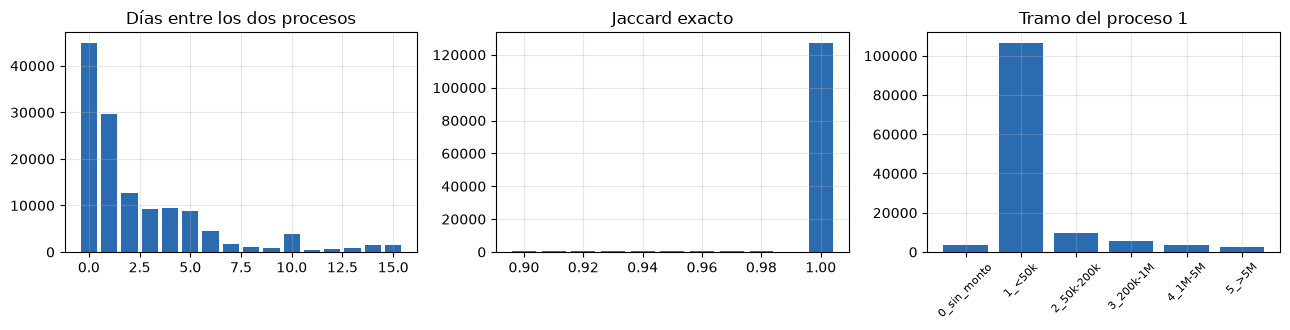

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
d = pares.groupBy("dias_diferencia").count().orderBy("dias_diferencia").toPandas()
ax[0].bar(d["dias_diferencia"], d["count"], color="#2b6cb0"); ax[0].set_title("Días entre los dos procesos")
j = pares.groupBy(F.round("jaccard", 2).alias("j")).count().orderBy("j").toPandas()
ax[1].bar(j["j"], j["count"], width=.008, color="#2b6cb0"); ax[1].set_title("Jaccard exacto")
t = pares.groupBy("tramo_1").count().orderBy("tramo_1").toPandas()
ax[2].bar(t["tramo_1"], t["count"], color="#2b6cb0"); ax[2].set_title("Tramo del proceso 1"); ax[2].tick_params(axis="x", rotation=45, labelsize=8)
mostrar_fig("tipos_pares")

- 131,473 pares con 37,094 procesos (15.7% del total) de 2,339 entidades

- El 96% de los pares tiene texto idéntico (126,445): la mayoría son descripciones plantilla repetidas; los 5,028 con texto distinto son los que aporta la similitud aproximada

- 30,372 pares (23%) suben de tramo al sumar sus montos, sobre todo de `<50k` a `50k–200k` (28,318)

### 3. Condiciones de P2

P2 pregunta por procesos **casi idénticos** de una **misma entidad**, en **fechas cercanas** y con **montos bajos**, que sugieran dividir una compra para **evadir un método más exigente**. Las tres primeras ya las aseguran los pares (Jaccard ≥ 0.90, misma entidad, ≤ 15 días); se marcan las demás:

- `casi_duplicado_eda`: mismo día, mismo texto y mismo monto; los casi-duplicados del EDA (posibles republicaciones), no fraccionamiento

- `montos_bajos`: los dos procesos bajo `CORTE_BAJO` = S/ 200k (tramos `1_<50k` y `2_50k-200k`). Sobre ese monto los métodos de compras chicas casi no se usan (Comparación de Precios 0%, Convenio 0.8%, Régimen Especial 1.0% de los procesos de 200k–1M), así que ya no queda un método menos exigente que evitar

- `salta_tramo`: la suma de ambos cae en un tramo superior

- `metodo_menos_exigente`: en el tramo de la suma, el método usado es mucho menos frecuente (menos de la mitad de su cuota en el tramo propio), en los dos procesos: con el monto total lo normal sería otro método. Las cuotas salen de la data (p. ej. Comparación de Precios: 12.3% de los procesos de 50k–200k y 0% de los de 200k–1M)

In [10]:
# cuota de cada método dentro de cada tramo (% de los procesos del tramo que lo usan)
cuotas = (procesos.where(F.col("metodo_detalle").isNotNull()).groupBy("tramo_monto", "metodo_detalle").count()
                  .withColumn("cuota", F.col("count") / F.sum("count").over(Window.partitionBy("tramo_monto")))
                  .select("tramo_monto", "metodo_detalle", "cuota"))
CORTE_BAJO = 200_000       # fin del tramo 2_50k-200k: sobre él casi no se usan los métodos de compras chicas (ver markdown)
CUOTA_RELATIVA = 0.5       # "mucho menos frecuente": en el tramo de la suma el método tiene menos de la mitad de su cuota propia;
                           # 0.5 separa los métodos de compras chicas (cuota cae 10x o más) de los que se usan igual en ambos tramos

def cuota(col_m, col_t, nombre):
    return cuotas.select(F.col("metodo_detalle").alias(col_m), F.col("tramo_monto").alias(col_t), F.col("cuota").alias(nombre))

def marcar_p2(df, corte=CORTE_BAJO, cuota_rel=CUOTA_RELATIVA):
    # marca en cada par las condiciones de P2 y los niveles acumulados n1..n4
    return (df.join(cuota("metodo_1", "tramo_1", "cuota_1"), ["metodo_1", "tramo_1"], "left")
              .join(cuota("metodo_2", "tramo_2", "cuota_2"), ["metodo_2", "tramo_2"], "left")
              .join(cuota("metodo_1", "tramo_suma", "cuota_1_suma"), ["metodo_1", "tramo_suma"], "left")
              .join(cuota("metodo_2", "tramo_suma", "cuota_2_suma"), ["metodo_2", "tramo_suma"], "left")
              .fillna(0.0, ["cuota_1_suma", "cuota_2_suma"])
              .withColumn("casi_duplicado_eda", F.col("texto_identico") & F.col("mismo_dia") & F.col("monto_final_1").eqNullSafe(F.col("monto_final_2")))
              .withColumn("montos_bajos", F.coalesce((F.col("monto_final_1") < corte) & (F.col("monto_final_2") < corte), F.lit(False)))
              .withColumn("salta_tramo", F.col("tramo_suma") > F.greatest("tramo_1", "tramo_2"))
              .withColumn("metodo_menos_exigente", F.coalesce((F.col("cuota_1_suma") < cuota_rel * F.col("cuota_1")) &
                                                              (F.col("cuota_2_suma") < cuota_rel * F.col("cuota_2")), F.lit(False)))
              .withColumn("n1", ~F.col("casi_duplicado_eda"))
              .withColumn("n2", F.col("n1") & F.col("montos_bajos"))
              .withColumn("n3", F.col("n2") & F.col("salta_tramo"))
              .withColumn("n4", F.col("n3") & F.col("metodo_menos_exigente")))

marcar_p2(pares).write.mode("overwrite").parquet(str(pares_p2_dir))
pares_p2 = spark.read.parquet(str(pares_p2_dir)).cache()

# niveles acumulados: cada uno agrega una condición de P2 a la anterior
NIVELES = [("1. casi idénticos, misma entidad, ≤ 15 días", F.lit(True)), ("2. sin casi-duplicados del EDA", F.col("n1")),
           ("3. + montos bajos (< 200k)", F.col("n2")), ("4. + la suma salta de tramo", F.col("n3")),
           ("5. + método poco usado en el tramo de la suma", F.col("n4"))]
filas = []
for nombre, cond in NIVELES:
    p_ = pares_p2.where(cond)
    filas.append({"nivel": nombre, "pares": p_.count(),
                  "procesos": p_.select(F.explode(F.array("ocid_1", "ocid_2"))).distinct().count(),
                  "entidades": p_.select("entidad").distinct().count()})
embudo = pd.DataFrame(filas)
embudo["pct_procesos"] = (100 * embudo["procesos"] / N).round(2)
embudo

,nivel,pares,procesos,entidades,pct_procesos
0,"1. casi idénticos, misma entidad, ≤ 15 días",131473,37094,2339,15.72
1,2. sin casi-duplicados del EDA,120643,31592,2233,13.39
2,3. + montos bajos (< 200k),107810,10590,1256,4.49
3,4. + la suma salta de tramo,26524,4847,860,2.05
4,5. + método poco usado en el tramo de la suma,24624,1549,33,0.66


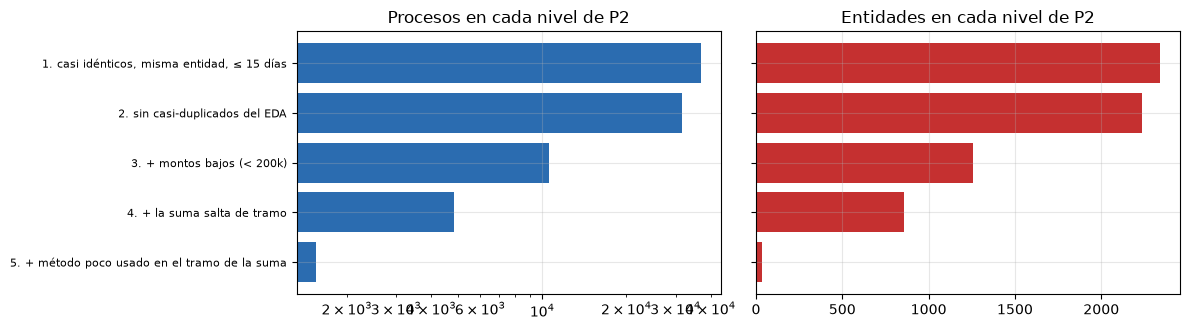

+-------------------------------------+----------+----------+-----+--------------+---------------+
|                             metodo_1|   tramo_1|tramo_suma|pares|cuota_propia_%|cuota_en_suma_%|
+-------------------------------------+----------+----------+-----+--------------+---------------+
|                     REGÍMEN ESPECIAL|    1_<50k|2_50k-200k|24487|          22.2|            0.9|
|                             CONVENIO|    1_<50k|2_50k-200k|  102|          13.4|            1.7|
|                             CONVENIO|2_50k-200k| 3_200k-1M|   11|           1.7|            0.8|
|SELECCIÓN DE CONSULTORES INDIVIDUALES|    1_<50k|2_50k-200k|   10|           0.1|            0.0|
|           CONTRATACIÓN INTERNACIONAL|    1_<50k|2_50k-200k|    9|           9.1|            0.9|
|               COMPARACIÓN DE PRECIOS|2_50k-200k| 3_200k-1M|    3|          12.3|            0.0|
|                             CONVENIO|    1_<50k| 3_200k-1M|    2|          13.4|            0.8|
+---------

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
y = np.arange(len(embudo))[::-1]
ax[0].barh(y, embudo["procesos"], color="#2b6cb0"); ax[0].set_yticks(y); ax[0].set_yticklabels(embudo["nivel"], fontsize=8)
ax[0].set_xscale("log"); ax[0].set_title("Procesos en cada nivel de P2")
ax[1].barh(y, embudo["entidades"], color="#c53030"); ax[1].set_yticks(y); ax[1].set_yticklabels([])
ax[1].set_title("Entidades en cada nivel de P2")
mostrar_fig("embudo_p2")

(pares_p2.where("n4").groupBy("metodo_1", "tramo_1", "tramo_suma")
         .agg(F.count("*").alias("pares"), F.round(F.first("cuota_1") * 100, 1).alias("cuota_propia_%"), F.round(F.first("cuota_1_suma") * 100, 1).alias("cuota_en_suma_%"))
         .orderBy(F.desc("pares")).show(8, truncate=40))

- Cada condición de P2 recorta mucho: de 37,094 procesos casi idénticos quedan 31,592 sin los casi-duplicados del EDA, 10,590 con montos bajos, 4,847 cuya suma salta de tramo y **1,549 (0.66%)** con un método poco usado en el tramo de la suma

- Esos 1,549 procesos son de solo 33 entidades, y OEFA aporta 1,388: Régimen Especial, que es el 22.2% de los procesos bajo 50k y solo el 0.9% entre 50k y 200k

- Fuera de OEFA el patrón completo aparece casi solo en **Convenio** (13.4% bajo 50k → 1.7% en 50k–200k), en unidades de proyectos (RENIEC, UNI, OSCE, MTC): p. ej. consultorías individuales idénticas de S/ 30k el mismo día

- Adjudicación Simplificada y Subasta Inversa casi no llegan al último nivel: su cuota se mantiene entre tramos, así que dividir la compra no cambia el método

### 4. Grupos (componentes conexas)

Si A~B y B~C, los tres son un grupo. Propagación de etiquetas en Spark: cada proceso toma el menor `ocid` de sus vecinos hasta converger

In [12]:
aristas = pares.select("ocid_1", "ocid_2").union(pares.select(F.col("ocid_2").alias("ocid_1"), F.col("ocid_1").alias("ocid_2")))
etiquetas = aristas.select(F.col("ocid_1").alias("ocid")).distinct().withColumn("grupo", F.col("ocid"))

# tope de 20 iteraciones: converge en tantas como el diámetro del grupo más largo (5 en la corrida)
for it in range(20):
    vecinos = aristas.join(etiquetas, aristas.ocid_2 == etiquetas.ocid).groupBy("ocid_1").agg(F.min("grupo").alias("g_vec"))
    nuevas = etiquetas.join(vecinos, etiquetas.ocid == vecinos.ocid_1, "left").select("ocid", F.least("grupo", "g_vec").alias("grupo")).cache()
    cambios = etiquetas.join(nuevas, "ocid").where(etiquetas.grupo != nuevas.grupo).count()
    etiquetas = nuevas
    if cambios == 0:
        break
grupos = etiquetas.groupBy("grupo").agg(F.count("*").alias("procesos_en_grupo"))
print(f"Convergió en {it + 1} iteraciones | grupos: {grupos.count():,}")
grupos.groupBy("procesos_en_grupo").count().orderBy("procesos_en_grupo").show()

Convergió en 5 iteraciones | grupos: 15,944


+-----------------+-----+
|procesos_en_grupo|count|
+-----------------+-----+
|                2|13793|
|                3| 1586|
|                4|  309|
|                5|   90|
|                6|   44|
|                7|   34|
|                8|    8|
|                9|    6|
|               10|    4|
|               11|   12|
|               12|    4|
|               13|    7|
|               14|    1|
|               15|    3|
|               16|    4|
|               17|    3|
|               18|    2|
|               19|    2|
|               20|    2|
|               21|    2|
+-----------------+-----+
only showing top 20 rows



In [13]:
info = etiquetas.join(procesos, "ocid").join(grupos, "grupo")
for g in info.where("procesos_en_grupo >= 3").select("grupo", "entidad", "procesos_en_grupo").distinct().orderBy(F.desc("procesos_en_grupo")).limit(3).collect():
    print(f"\n=== {g['entidad']} — {g['procesos_en_grupo']} procesos")
    (info.where(F.col("grupo") == g["grupo"]).orderBy("fecha")
         .select(F.date_format("fecha", "yyyy-MM-dd").alias("fecha"), F.round("monto_final").alias("monto"), F.substring("descripcion", 1, 90).alias("descripcion"))
         .show(8, truncate=False))


=== ORGANISMO DE EVALUACION Y FISCALIZACION AMBIENTAL — 481 procesos


+----------+-------+---------------------------------+
|fecha     |monto  |descripcion                      |
+----------+-------+---------------------------------+
|2025-02-14|8000.0 |SERVICIO DE SUPERVISIÓN AMBIENTAL|
|2025-02-14|24000.0|SERVICIO DE SUPERVISIÓN AMBIENTAL|
|2025-02-14|18000.0|SERVICIO DE SUPERVISIÓN AMBIENTAL|
|2025-02-14|24000.0|SERVICIO DE SUPERVISIÓN AMBIENTAL|
|2025-02-14|4000.0 |SERVICIO DE SUPERVISIÓN AMBIENTAL|
|2025-02-14|3000.0 |SERVICIO DE SUPERVISIÓN AMBIENTAL|
|2025-02-14|18000.0|SERVICIO DE SUPERVISIÓN AMBIENTAL|
|2025-02-14|30000.0|SERVICIO DE SUPERVISIÓN AMBIENTAL|
+----------+-------+---------------------------------+
only showing top 8 rows


=== ORGANISMO DE EVALUACION Y FISCALIZACION AMBIENTAL — 160 procesos


+----------+-------+-------------------------------------------+
|fecha     |monto  |descripcion                                |
+----------+-------+-------------------------------------------+
|2025-03-19|48000.0|SERVICIO DE EVALUACIÓN EN TEMAS AMBIENTALES|
|2025-03-19|36000.0|SERVICIO DE EVALUACIÓN EN TEMAS AMBIENTALES|
|2025-03-19|36000.0|SERVICIO DE EVALUACIÓN EN TEMAS AMBIENTALES|
|2025-03-19|36000.0|SERVICIO DE EVALUACIÓN EN TEMAS AMBIENTALES|
|2025-03-19|48000.0|SERVICIO DE EVALUACIÓN EN TEMAS AMBIENTALES|
|2025-03-19|48000.0|SERVICIO DE EVALUACIÓN EN TEMAS AMBIENTALES|
|2025-03-19|48000.0|SERVICIO DE EVALUACIÓN EN TEMAS AMBIENTALES|
|2025-03-19|48000.0|SERVICIO DE EVALUACIÓN EN TEMAS AMBIENTALES|
+----------+-------+-------------------------------------------+
only showing top 8 rows


=== ORGANISMO DE EVALUACION Y FISCALIZACION AMBIENTAL — 154 procesos


+----------+-------+-----------------------------------+
|fecha     |monto  |descripcion                        |
+----------+-------+-----------------------------------+
|2025-02-14|16000.0|SERVICIO DE FISCALIZACIÓN AMBIENTAL|
|2025-02-14|12000.0|SERVICIO DE FISCALIZACIÓN AMBIENTAL|
|2025-02-14|20000.0|SERVICIO DE FISCALIZACIÓN AMBIENTAL|
|2025-02-14|20000.0|SERVICIO DE FISCALIZACIÓN AMBIENTAL|
|2025-02-14|12000.0|SERVICIO DE FISCALIZACIÓN AMBIENTAL|
|2025-02-14|12000.0|SERVICIO DE FISCALIZACIÓN AMBIENTAL|
|2025-02-14|16000.0|SERVICIO DE FISCALIZACIÓN AMBIENTAL|
|2025-02-14|12000.0|SERVICIO DE FISCALIZACIÓN AMBIENTAL|
+----------+-------+-----------------------------------+
only showing top 8 rows



- 15,944 grupos; el 87% son de 2 procesos, pero OEFA forma grupos de cientos (481, 160 y 154 procesos) con la misma descripción y montos de S/ 3k–48k

### 5. Rate de fraccionamiento

- **Numerador:** procesos distintos de la entidad en algún par ≥ `UMBRAL` (se cuentan procesos, no pares: un grupo de 4 genera 6 pares)

- **Denominador:** total de procesos de la entidad 2023-2025

- `rate = sospechosos / total`; `uno_de_cada = total / sospechosos`

- `rate_estricto`: excluye los casi-duplicados del EDA (mismo día, texto y monto)

- `rate_p2`: solo procesos que cumplen todas las condiciones de P2 (nivel 5)

- `monto_sospechoso`: suma del monto de los procesos distintos en algún par (cada proceso una sola vez)

In [14]:
def procesos_por_entidad(p, nombre):
    return (p.select("entidad", F.explode(F.array("ocid_1", "ocid_2")).alias("ocid")).distinct()
             .groupBy("entidad").agg(F.count("*").alias(nombre)))

total_ent = procesos.groupBy("entidad").agg(F.count("*").alias("procesos_total"), F.first("region").alias("region"))
sosp   = procesos_por_entidad(pares_p2, "procesos_sospechosos")
sosp_e = procesos_por_entidad(pares_p2.where("n1"), "procesos_sospechosos_estricto")
sosp_p2 = procesos_por_entidad(pares_p2.where("n4"), "procesos_p2")
monto_e = (pares_p2.select("entidad", F.explode(F.array("ocid_1", "ocid_2")).alias("ocid")).distinct()
                   .join(procesos.select("ocid", "monto_final"), "ocid").groupBy("entidad").agg(F.sum("monto_final").alias("monto_sospechoso")))
par_e = pares_p2.groupBy("entidad").agg(F.count("*").alias("pares"), F.round(F.avg("dias_diferencia"), 1).alias("dias_promedio"))
gru_e = etiquetas.join(procesos.select("ocid", "entidad"), "ocid").select("entidad", "grupo").distinct().groupBy("entidad").agg(F.count("*").alias("grupos"))

entidades = (total_ent.join(sosp, "entidad", "left").join(sosp_e, "entidad", "left").join(sosp_p2, "entidad", "left")
                      .join(monto_e, "entidad", "left").join(par_e, "entidad", "left").join(gru_e, "entidad", "left")
                      .fillna(0, ["procesos_sospechosos", "procesos_sospechosos_estricto", "procesos_p2", "pares", "grupos", "monto_sospechoso"])
                      .withColumn("rate", F.round(F.col("procesos_sospechosos") / F.col("procesos_total"), 4))
                      .withColumn("rate_estricto", F.round(F.col("procesos_sospechosos_estricto") / F.col("procesos_total"), 4))
                      .withColumn("rate_p2", F.round(F.col("procesos_p2") / F.col("procesos_total"), 4))
                      .withColumn("uno_de_cada", F.when(F.col("procesos_sospechosos") > 0, F.round(F.col("procesos_total") / F.col("procesos_sospechosos"), 1))))
entidades.write.mode("overwrite").parquet(str(entidades_dir))
entidades = spark.read.parquet(str(entidades_dir)).cache()

def totales(df):
    return df.agg(F.sum("procesos_total").alias("t"), F.sum("procesos_sospechosos").alias("s"),
                  F.sum("procesos_sospechosos_estricto").alias("se"), F.sum("procesos_p2").alias("p2")).first()

ES_OEFA = F.col("entidad").contains("FISCALIZACION AMBIENTAL")   # OEFA: aporta el 83% de los pares (§2), se mide aparte
tot, tot_sin = totales(entidades), totales(entidades.where(~ES_OEFA))
for nombre, t_ in [("Todas las entidades", tot), ("Sin OEFA", tot_sin)]:
    print(f"{nombre}: rate {t_['s'] / t_['t']:.2%} (1 de cada {t_['t'] / max(t_['s'], 1):.0f}) | "
          f"estricto {t_['se'] / t_['t']:.2%} | P2 completo {t_['p2'] / t_['t']:.2%} ({t_['p2']:,} procesos)")
print(f"Pares sin OEFA: {pares_p2.where(~ES_OEFA).count():,} de {n_pares:,}")
print(f"Entidades con pares: {entidades.where('pares > 0').count():,} de {entidades.count():,} | con procesos P2: {entidades.where('procesos_p2 > 0').count():,}")

Todas las entidades: rate 15.72% (1 de cada 6) | estricto 13.39% | P2 completo 0.66% (1,549 procesos)
Sin OEFA: rate 14.66% (1 de cada 7) | estricto 12.31% | P2 completo 0.07% (161 procesos)
Pares sin OEFA: 22,233 de 131,473
Entidades con pares: 2,339 de 2,995 | con procesos P2: 33


- Rate global: 1 de cada 6 procesos (15.7%) aparece en algún par; estricto (sin casi-duplicados del EDA): 13.4%

- Con todas las condiciones de P2 el rate cae a 0.66% (1,549 procesos)

- Sin OEFA: rate 14.7% y estricto 12.3%, pero el patrón completo de P2 baja a 0.07% (161 procesos); OEFA concentra 109,240 de los 131,473 pares (83%)

### 6. Ranking de entidades

Solo entidades con ≥ `MIN_PROC` procesos, para que una entidad chica no encabece la lista con 2 casos

In [15]:
MIN_PROC = 50              # con menos procesos, 1–2 pares ya dan un rate alto que no es comparable
(entidades.where(f"procesos_total >= {MIN_PROC} AND pares > 0").orderBy(F.desc("rate"))
          .select("entidad", "region", "procesos_total", "procesos_sospechosos", "procesos_p2", "pares", "rate", "rate_estricto", "rate_p2").show(15, truncate=45))
(entidades.orderBy(F.desc("pares"))
          .select("entidad", "procesos_total", "procesos_sospechosos", "pares", "grupos", F.round("monto_sospechoso").alias("monto_sospechoso"), "rate").show(10, truncate=45))

+---------------------------------------------+-------------------------+--------------+--------------------+-----------+------+------+-------------+-------+
|                                      entidad|                   region|procesos_total|procesos_sospechosos|procesos_p2| pares|  rate|rate_estricto|rate_p2|
+---------------------------------------------+-------------------------+--------------+--------------------+-----------+------+------+-------------+-------+
|ORGANISMO DE EVALUACION Y FISCALIZACION AM...|                     LIMA|          3501|                3016|       1388|109240|0.8615|       0.8472| 0.3965|
|GOBIERNO REGIONAL DE UCAYALI - DIRECCIÓN R...|         CORONEL PORTILLO|           171|                 120|          0|   328|0.7018|       0.7018|    0.0|
|INSTITUTO VIAL PROVINCIAL DE PASCO - IVP-P...|                    PASCO|           163|                 110|          0|    61|0.6748|        0.638|    0.0|
|INSTITUTO VIAL PROVINCIAL MUNICIPAL DE PAC...|     

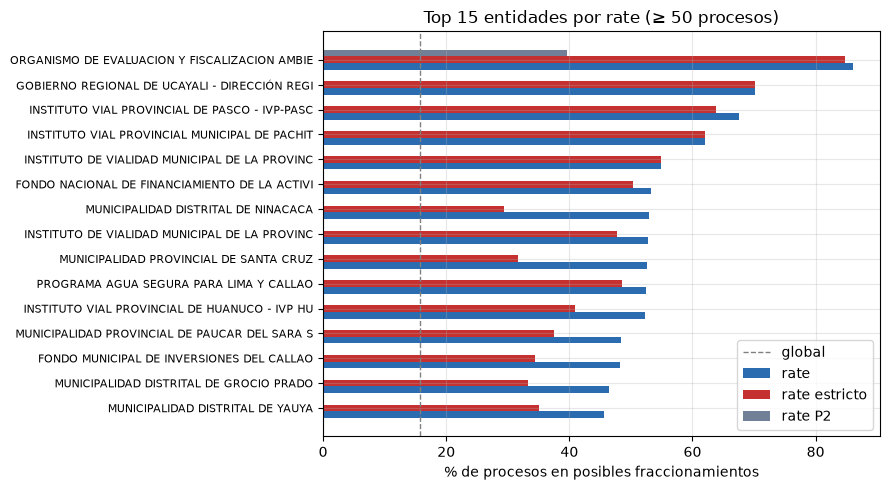

In [16]:
top = entidades.where(f"procesos_total >= {MIN_PROC} AND pares > 0").orderBy(F.desc("rate")).limit(15).select("entidad", "rate", "rate_estricto", "rate_p2").toPandas().iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5)); y = np.arange(len(top))
ax.barh(y - .27, top["rate"] * 100, .27, label="rate", color="#2b6cb0"); ax.barh(y, top["rate_estricto"] * 100, .27, label="rate estricto", color="#c53030")
ax.barh(y + .27, top["rate_p2"] * 100, .27, label="rate P2", color="#718096")
ax.axvline(tot["s"] / tot["t"] * 100, color="gray", ls="--", lw=1, label="global")
ax.set_yticks(y); ax.set_yticklabels(top["entidad"].str[:45], fontsize=8); ax.set_xlabel("% de procesos en posibles fraccionamientos")
ax.set_title(f"Top 15 entidades por rate (≥ {MIN_PROC} procesos)"); ax.legend(); mostrar_fig("ranking_rate")

- OEFA lidera: 86% de sus procesos en algún par y 40% con el patrón completo de P2

- Le siguen el GORE Ucayali (70%) y varios institutos viales provinciales (Pasco, Pachitea, Chachapoyas, Huancavelica, Huánuco, 52–67%), pero sin procesos de P2 completo: sus pares no cumplen montos bajos o salto de tramo con cambio de método

- Por monto, CENARES y EsSalud (S/ 3.2 y 3.8 mil millones en procesos de algún par) tienen rate bajo (30% y 11%): son compras grandes repetidas, no fraccionamiento de montos bajos

### 7. Variación del resultado

- Se cambia **un parámetro a la vez** (el resto queda en su valor elegido) y se mide cómo cambia la respuesta a P2, no el error de la técnica (eso está en `b_lsh`)

- `UMBRAL` 0.80 / 0.95 y `VENTANA_DIAS` 7 / 28: 0.95 y 7 filtran los pares ya calculados; 0.80 y 28 vuelven a correr LSH sobre los 36 meses. 28 es el máximo que permite cargar solo el mes y el siguiente

- `CORTE_BAJO` S/ 100k / 500k y `CUOTA_RELATIVA` 0.3 / 0.7: filtros sobre los mismos pares

- Con `UMBRAL` = 0.80, LSH (umbral 0.79) pierde ~0.25% de los pares reales (`b_lsh` §6): no cambia la lectura

In [17]:
procesos_sim = spark.read.parquet(str(final_dir)).select(*COLS_SIMILITUD)
firmas = spark.read.parquet(str(firmas_dir))
meses = [(r_["anio"], r_["mes"]) for r_ in procesos_sim.select("anio", "mes").distinct().orderBy("anio", "mes").collect()]
var_dir = out_dir / "variacion"

def pares_con(umbral, ventana):
    # mismos pasos de c_pares con otro umbral o ventana; se guarda para no repetirlo
    destino = var_dir / f"pares_u{int(round(umbral * 100))}_v{ventana}"
    if not (destino / "_SUCCESS").exists():
        if destino.exists():
            shutil.rmtree(destino)
        for anio, mes in meses:
            p_, f_ = procesos_sim.where(filtro_meses(anio, mes)), firmas.where(filtro_meses(anio, mes))
            verificar_pares(candidatos_lsh(lsh_bandas(f_), anio, mes, ventana=ventana), p_, f_, umbral=umbral) \
                .write.mode("append").parquet(str(destino))
        (destino / "_SUCCESS").touch()
    return spark.read.parquet(str(destino))

def ocids(df):
    return df.select(F.explode(F.array("ocid_1", "ocid_2")).alias("ocid")).distinct()

# un parámetro a la vez, con un valor a cada lado del elegido; el resto queda fijo
CONFIGS = [("elegido", "—", UMBRAL, VENTANA_DIAS, CORTE_BAJO, CUOTA_RELATIVA),
           ("UMBRAL", 0.80, 0.80, VENTANA_DIAS, CORTE_BAJO, CUOTA_RELATIVA), ("UMBRAL", 0.95, 0.95, VENTANA_DIAS, CORTE_BAJO, CUOTA_RELATIVA),
           ("VENTANA_DIAS", 7, UMBRAL, 7, CORTE_BAJO, CUOTA_RELATIVA), ("VENTANA_DIAS", 28, UMBRAL, 28, CORTE_BAJO, CUOTA_RELATIVA),
           ("CORTE_BAJO", 100_000, UMBRAL, VENTANA_DIAS, 100_000, CUOTA_RELATIVA), ("CORTE_BAJO", 500_000, UMBRAL, VENTANA_DIAS, 500_000, CUOTA_RELATIVA),
           ("CUOTA_RELATIVA", 0.3, UMBRAL, VENTANA_DIAS, CORTE_BAJO, 0.3), ("CUOTA_RELATIVA", 0.7, UMBRAL, VENTANA_DIAS, CORTE_BAJO, 0.7)]

filas = []
for param, valor, u, v, corte, cr in CONFIGS:
    base = (pares.where((F.col("jaccard") >= u) & (F.col("dias_diferencia") <= v))
            if u >= UMBRAL and v <= VENTANA_DIAS else pares_con(u, v))
    m = marcar_p2(base, corte, cr).cache()
    p2 = m.where("n4")
    n_casi, n_p2 = ocids(m).count(), ocids(p2).count()
    filas.append({"parametro": param, "valor": str(valor), "pares": m.count(),
                  "procesos_casi_identicos": n_casi, "pct_casi_identicos": round(100 * n_casi / N, 2),
                  "procesos_p2": n_p2, "pct_p2": round(100 * n_p2 / N, 2),
                  "pct_p2_oefa": round(100 * ocids(p2.where(ES_OEFA)).count() / max(n_p2, 1), 1),
                  "entidades_p2": p2.select("entidad").distinct().count(),
                  "entidades_p2_sin_oefa": p2.where(~ES_OEFA).select("entidad").distinct().count()})
    m.unpersist()
variacion = pd.DataFrame(filas)
variacion

,parametro,valor,pares,procesos_casi_identicos,pct_casi_identicos,procesos_p2,pct_p2,pct_p2_oefa,entidades_p2,entidades_p2_sin_oefa
0,elegido,—,131473,37094,15.72,1549,0.66,89.6,33,32
1,UMBRAL,0.8,143367,47197,20.00,1724,0.73,81.3,40,39
2,UMBRAL,0.95,128738,34139,14.47,1483,0.63,93.6,25,24
3,VENTANA_DIAS,7,120725,31552,13.37,1395,0.59,91.5,26,25
4,VENTANA_DIAS,28,149893,48970,20.75,1592,0.67,87.5,39,38
5,CORTE_BAJO,100000,131473,37094,15.72,1517,0.64,91.5,21,20
6,CORTE_BAJO,500000,131473,37094,15.72,1549,0.66,89.6,33,32
7,CUOTA_RELATIVA,0.3,131473,37094,15.72,1523,0.65,91.1,24,23
8,CUOTA_RELATIVA,0.7,131473,37094,15.72,1549,0.66,89.6,33,32


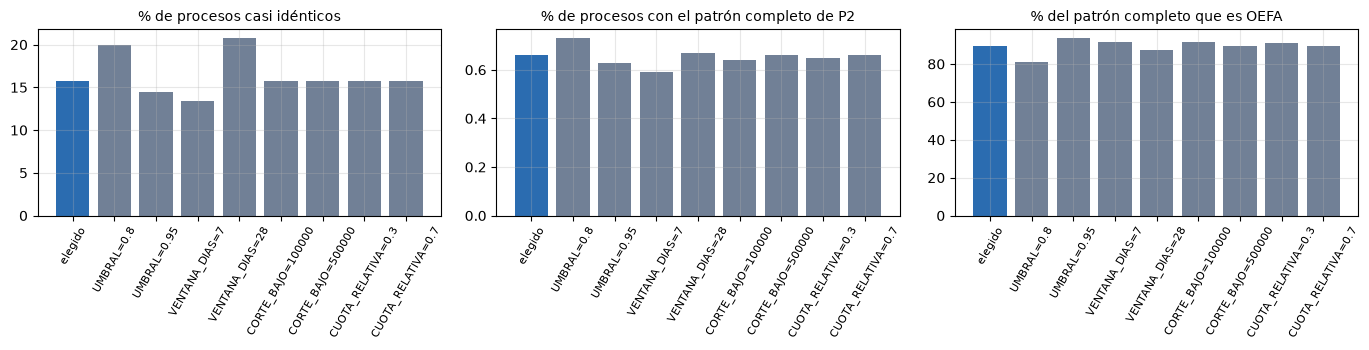

In [18]:
etiquetas = [f"{p}={v}" if p != "elegido" else "elegido" for p, v in zip(variacion["parametro"], variacion["valor"])]
colores = ["#2b6cb0" if p == "elegido" else "#718096" for p in variacion["parametro"]]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for a_, col, titulo in [(ax[0], "pct_casi_identicos", "% de procesos casi idénticos"), (ax[1], "pct_p2", "% de procesos con el patrón completo de P2"),
                        (ax[2], "pct_p2_oefa", "% del patrón completo que es OEFA")]:
    a_.bar(etiquetas, variacion[col], color=colores); a_.set_title(titulo, fontsize=10); a_.tick_params(axis="x", rotation=60, labelsize=8)
mostrar_fig("variacion_p2")

- **Lo que más se mueve es cuántos procesos son casi idénticos:** 13.4% con ventana de 7 días y 20.8% con 28; 14.5% con `UMBRAL` 0.95 y 20.0% con 0.80. Es la parte de la definición que depende de "qué tan parecido" y "qué tan cerca"

- **El patrón completo de P2 casi no cambia:** entre 0.59% y 0.73% en todas las variaciones (elegido 0.66%). Las condiciones de montos bajos y cambio de método filtran casi lo mismo

- **OEFA sigue siendo la mayoría en todos los casos:** entre 81% y 94% del patrón completo

- `CORTE_BAJO` = 500k y `CUOTA_RELATIVA` = 0.7 dan exactamente lo mismo que el valor elegido: ningún par adicional entre S/ 200k y 500k cumple las demás condiciones, y ningún método baja su cuota a entre 0.5 y 0.7 veces; los valores elegidos ya están en la zona estable

- Conclusión: la respuesta a P2 (patrón completo raro y dominado por OEFA) no depende de los parámetros elegidos

### 8. Escritura de resultados

- `temp/d_entidades/pares_p2`: pares con las condiciones de P2 marcadas (insumo de `e_analisis`)

- `temp/d_entidades/entidades`: rate por entidad

- Tablas en `temp/d_entidades/tablas` (parquet) y `web/` (json)

In [19]:
tipos = pares_p2.groupBy("texto_identico", "mismo_dia").count().toPandas()
tam_grupos = grupos.groupBy("procesos_en_grupo").count().orderBy("procesos_en_grupo").toPandas()
ranking = (entidades.where(f"procesos_total >= {MIN_PROC} AND pares > 0").orderBy(F.desc("rate")).limit(30)
                    .select("entidad", "region", "procesos_total", "procesos_sospechosos", "procesos_p2", "rate", "rate_estricto", "rate_p2", "monto_sospechoso"))
resumen = pd.DataFrame([{"alcance": n, "procesos": t_["t"], "rate": round(t_["s"] / t_["t"], 4), "rate_estricto": round(t_["se"] / t_["t"], 4),
                         "rate_p2": round(t_["p2"] / t_["t"], 4)} for n, t_ in [("todas", tot), ("sin_oefa", tot_sin)]])
tablas = {"embudo_p2": embudo, "variacion_p2": variacion, "tipos_pares": tipos, "tamano_grupos": tam_grupos, "ranking": ranking, "resumen": resumen}
escritos = {nombre: guardar_tabla(df, nombre) for nombre, df in tablas.items()}
print(f"Escrito en temp/d_entidades/: pares_p2, entidades, {', '.join(escritos)}")

Escrito en temp/d_entidades/: pares_p2, entidades, embudo_p2, variacion_p2, tipos_pares, tamano_grupos, ranking, resumen


#### a. Verificación

In [20]:
assert spark.read.parquet(str(pares_p2_dir)).count() == n_pares, "pares_p2 debe tener todos los pares"

for nombre, n in escritos.items():
    leido = spark.read.parquet(str(tab_dir / nombre)).count()
    assert leido == n, f"{nombre}: esperaba {n}, leí {leido}"
    assert (web_dir / f"{nombre}.json").exists(), f"falta web/{nombre}.json"

figs = sorted(p.stem for p in fig_dir.glob("*.png"))
print(f"OK: {len(escritos)} tablas (parquet + json) | {len(figs)} figuras: {', '.join(figs)}")

OK: 6 tablas (parquet + json) | 4 figuras: embudo_p2, ranking_rate, tipos_pares, variacion_p2


---
### 9. Cerrar sesión

In [21]:
spark.stop()